# Grafik 5 - Gabungan 1-4

Jalankan semua sel dari atas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Kelas C_Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


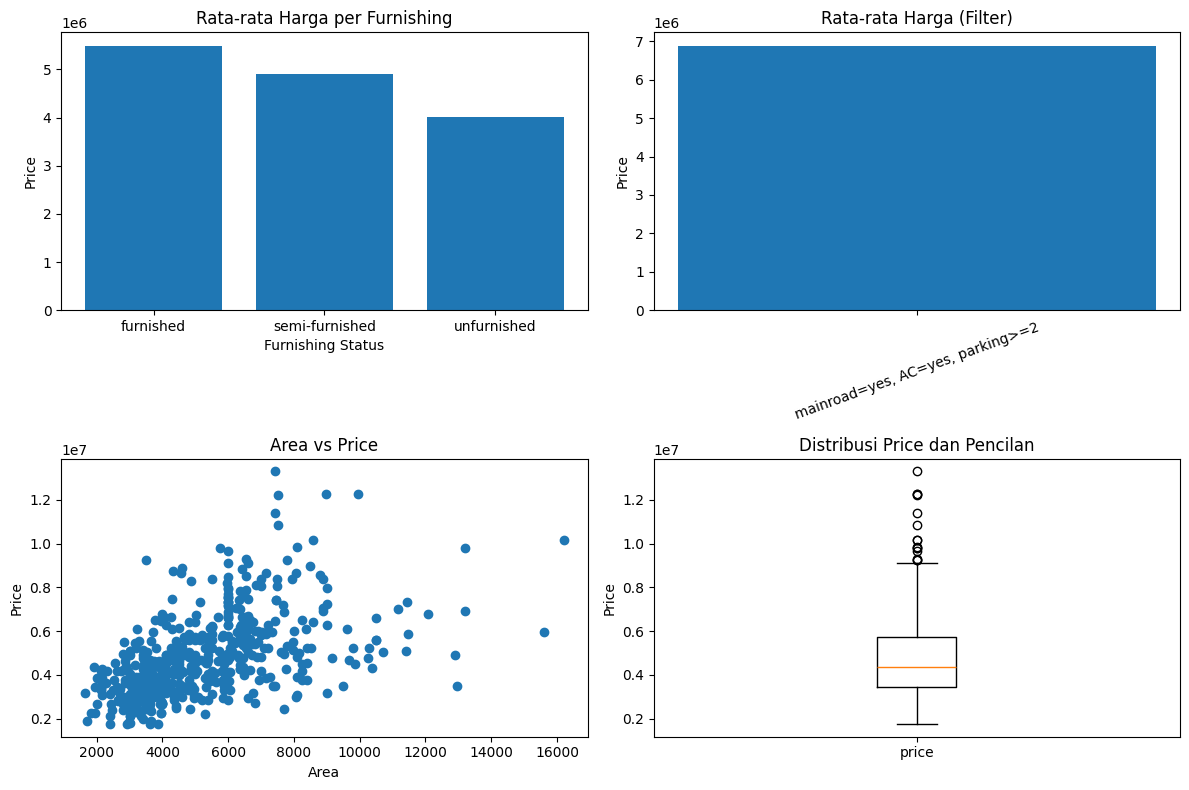

In [2]:
price_by_furniture = df.groupby("furnishingstatus")["price"].mean().sort_values(ascending=False)
filtered = df[(df["mainroad"] == "yes") & (df["airconditioning"] == "yes") & (df["parking"] >= 2)]
filtered_mean = filtered["price"].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(price_by_furniture.index, price_by_furniture.values)
axes[0, 0].set_title("Rata-rata Harga per Furnishing")
axes[0, 0].set_xlabel("Furnishing Status")
axes[0, 0].set_ylabel("Price")

axes[0, 1].bar(["mainroad=yes, AC=yes, parking>=2"], [filtered_mean])
axes[0, 1].set_title("Rata-rata Harga (Filter)")
axes[0, 1].set_ylabel("Price")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[1, 0].scatter(df["area"], df["price"])
axes[1, 0].set_title("Area vs Price")
axes[1, 0].set_xlabel("Area")
axes[1, 0].set_ylabel("Price")

axes[1, 1].boxplot(df["price"])
axes[1, 1].set_title("Distribusi Price dan Pencilan")
axes[1, 1].set_ylabel("Price")
axes[1, 1].set_xticklabels(["price"])

plt.tight_layout()